# Ragasa and Yagi RMSE / ACC plots

Plot the global RMSE and ACC results for five AI weather models against ERA5.

Saved E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig3\output\ragasa_rmse_acc.tif


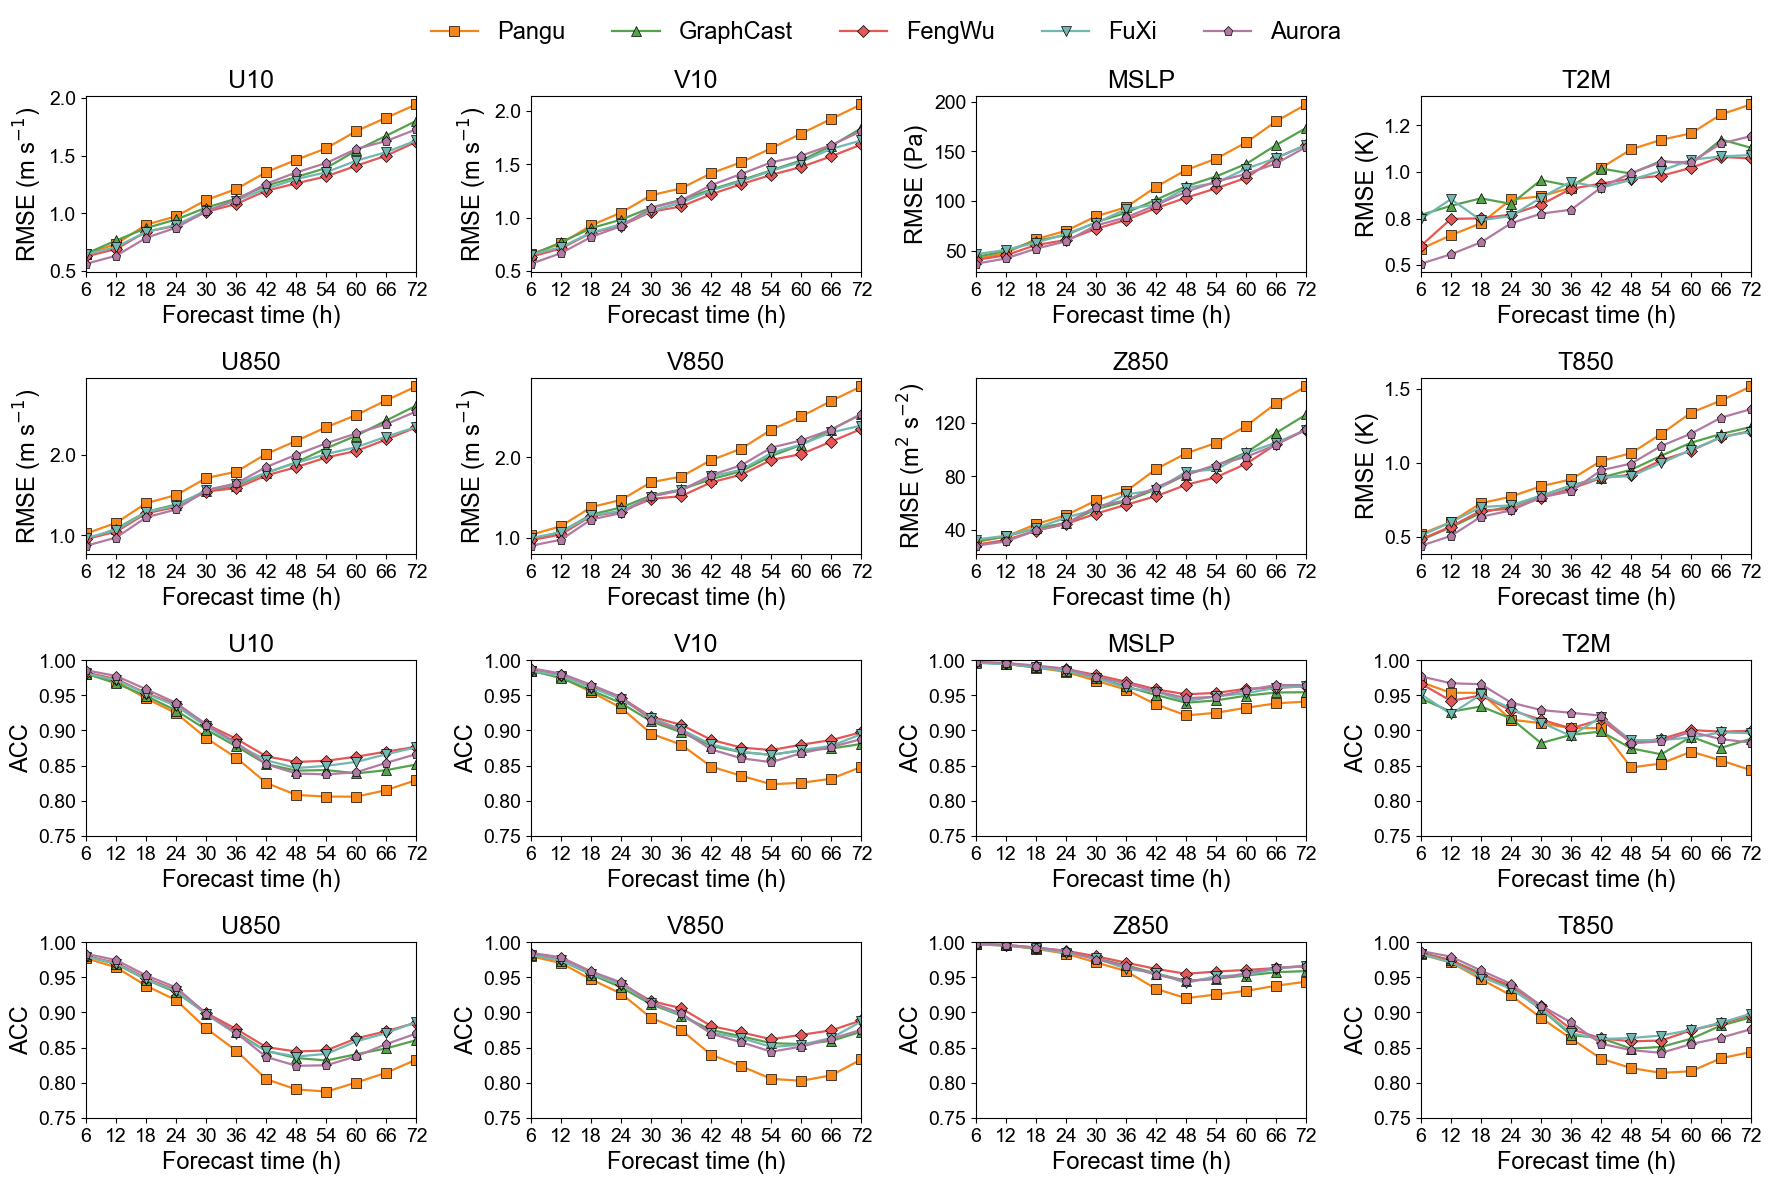

Saved E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig3\output\yagi_rmse_acc.tif


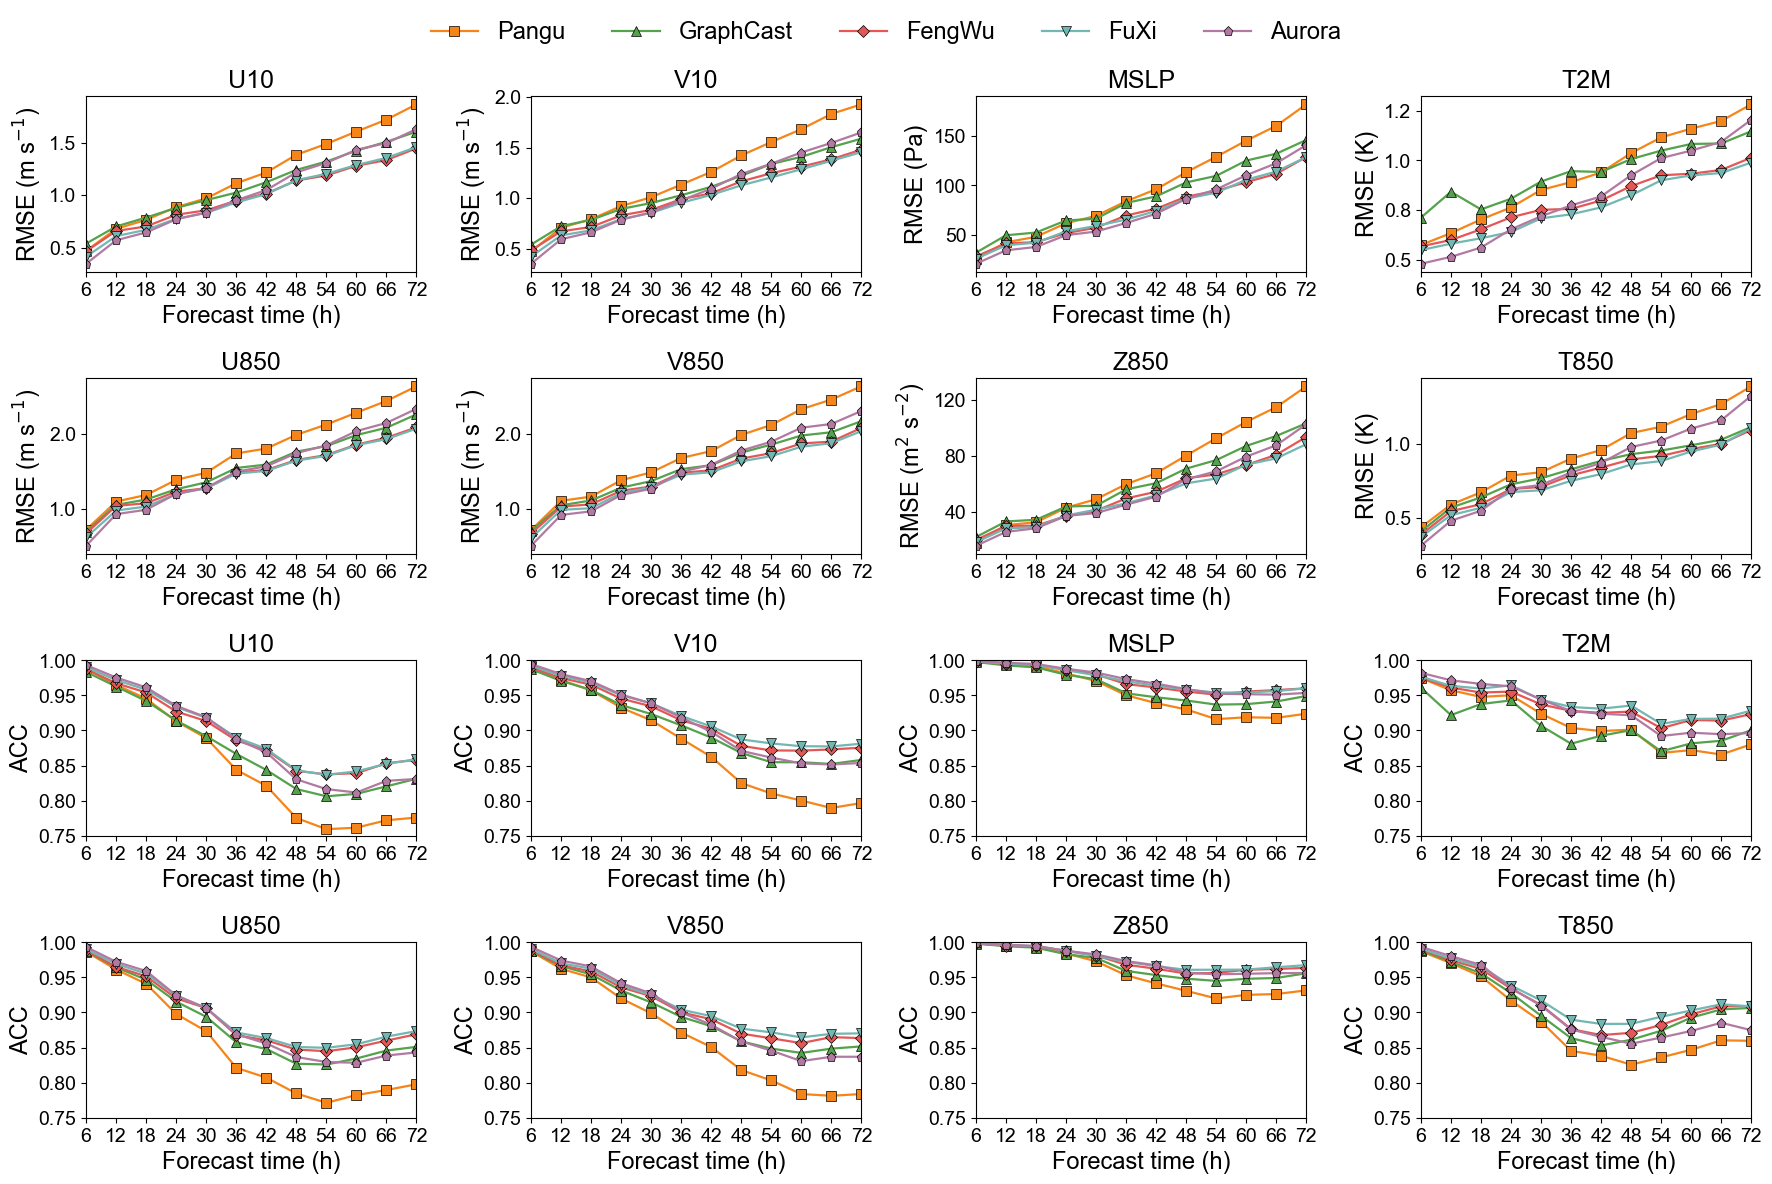

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MaxNLocator, MultipleLocator

EVENTS = ("ragasa", "yagi")
METRICS = ("rmse", "acc")
DATA_DIR = Path("./output")
OUTPUT_DIR = Path("./output")
OUTPUT_FILES = {
    event_name: OUTPUT_DIR / f"{event_name}_rmse_acc.tif"
    for event_name in EVENTS
}

MODEL_STYLES = {
    "pangu": {"label": "Pangu", "color": "#f58518", "marker": "s"},
    "graphcast": {"label": "GraphCast", "color": "#54a24b", "marker": "^"},
    "fengwu": {"label": "FengWu", "color": "#e45756", "marker": "D"},
    "fuxi": {"label": "FuXi", "color": "#72b7b2", "marker": "v"},
    "aurora": {"label": "Aurora", "color": "#b279a2", "marker": "p"},
}

VARIABLE_METADATA = {
    "U10": {"title": "U10", "unit": "m s$^{-1}$"},
    "V10": {"title": "V10", "unit": "m s$^{-1}$"},
    "MSLP": {"title": "MSLP", "unit": "Pa"},
    "T2M": {"title": "T2M", "unit": "K"},
    "U850": {"title": "U850", "unit": "m s$^{-1}$"},
    "V850": {"title": "V850", "unit": "m s$^{-1}$"},
    "Z850": {"title": "Z850", "unit": "m$^2$ s$^{-2}$"},
    "T850": {"title": "T850", "unit": "K"},
}

PLOT_SETTINGS = {
    "figure_size": (18, 12),
    "title_fontsize": 18,
    "label_fontsize": 17,
    "text_fontsize": 14,
    "line_width": 1.6,
    "marker_size": 6.5,
    "acc_tick_step": 0.05,
    "rmse_sparse_integer_nbins": 4,
}

EXPECTED_FORECAST_HOURS = np.arange(6, 73, 6)
REQUIRED_COLUMNS = ["forecast_hour", "valid_time", *VARIABLE_METADATA]

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 16,
})


def validate_metric_frame(metric_frame, file_path, metric_name):
    missing_columns = set(REQUIRED_COLUMNS).difference(metric_frame.columns)
    if missing_columns:
        raise ValueError(f"{file_path} is missing columns: {sorted(missing_columns)}")

    if len(metric_frame) != len(EXPECTED_FORECAST_HOURS):
        raise ValueError(
            f"{file_path} has {len(metric_frame)} rows; "
            f"expected {len(EXPECTED_FORECAST_HOURS)}"
        )

    forecast_hours = pd.to_numeric(
        metric_frame["forecast_hour"], errors="raise"
    ).to_numpy(dtype=int)
    if not np.array_equal(forecast_hours, EXPECTED_FORECAST_HOURS):
        raise ValueError(f"Unexpected forecast hours in {file_path}: {forecast_hours}")

    if metric_frame[REQUIRED_COLUMNS].isna().any().any():
        raise ValueError(f"Missing values found in {file_path}")

    metric_values = metric_frame[list(VARIABLE_METADATA)].apply(
        pd.to_numeric, errors="raise"
    ).to_numpy(dtype=float)
    if not np.isfinite(metric_values).all():
        raise ValueError(f"Non-finite values found in {file_path}")
    if metric_name == "rmse" and np.any(metric_values < 0):
        raise ValueError(f"Negative RMSE values found in {file_path}")
    if metric_name == "acc" and np.any(
        (metric_values < -1.000001) | (metric_values > 1.000001)
    ):
        raise ValueError(f"ACC values outside [-1, 1] found in {file_path}")


def load_metric_table(event_name, metric_name):
    metric_frames = []
    expected_valid_times = None

    for model_name in MODEL_STYLES:
        file_path = DATA_DIR / f"{event_name}_{model_name}_era5_{metric_name}.csv"
        if not file_path.exists():
            raise FileNotFoundError(f"Missing file: {file_path.resolve()}")

        metric_frame = pd.read_csv(file_path)
        validate_metric_frame(metric_frame, file_path, metric_name)

        valid_times = metric_frame["valid_time"].astype(str).to_numpy()
        if expected_valid_times is None:
            expected_valid_times = valid_times
        elif not np.array_equal(valid_times, expected_valid_times):
            raise ValueError(f"Valid-time mismatch in {file_path}")

        metric_frame = metric_frame.copy()
        metric_frame["forecast_hour"] = EXPECTED_FORECAST_HOURS
        metric_frame["model"] = model_name
        metric_frames.append(metric_frame)

    metric_table = pd.concat(metric_frames, ignore_index=True)
    return metric_table.melt(
        id_vars=["model", "forecast_hour", "valid_time"],
        value_vars=list(VARIABLE_METADATA),
        var_name="variable",
        value_name=metric_name,
    )


def prepare_metric_summary(event_name, metric_name):
    return (
        load_metric_table(event_name, metric_name)
        .sort_values(["variable", "model", "forecast_hour"])
        .reset_index(drop=True)
    )


def rmse_tick_formatter(value, _position):
    return f"{value:.1f}"


def integer_tick_formatter(value, _position):
    return f"{value:.0f}"


def get_shared_acc_ticks(metric_summary_frame):
    tick_step = PLOT_SETTINGS["acc_tick_step"]
    acc_min = metric_summary_frame["acc"].min()
    acc_max = metric_summary_frame["acc"].max()
    lower = np.floor(acc_min / tick_step) * tick_step
    upper = np.ceil(acc_max / tick_step) * tick_step
    ticks = np.arange(lower, upper + tick_step * 0.5, tick_step)
    return lower, upper, np.round(ticks, 2)


def apply_rmse_axis_format(axis, variable_name):
    if variable_name in {"U10", "V10"}:
        axis.yaxis.set_major_locator(MultipleLocator(0.5))
        axis.yaxis.set_major_formatter(FuncFormatter(rmse_tick_formatter))
        return

    if variable_name in {"MSLP", "Z850"}:
        axis.yaxis.set_major_locator(
            MaxNLocator(
                integer=True,
                nbins=PLOT_SETTINGS["rmse_sparse_integer_nbins"],
            )
        )
        axis.yaxis.set_major_formatter(FuncFormatter(integer_tick_formatter))
        return

    axis.yaxis.set_major_formatter(FuncFormatter(rmse_tick_formatter))


def plot_variable_series(axis, variable_summary, metric_name, model_order):
    legend_handles = []

    for model_name in model_order:
        model_summary = (
            variable_summary.loc[variable_summary["model"] == model_name]
            .sort_values("forecast_hour")
            .reset_index(drop=True)
        )
        style = MODEL_STYLES[model_name]
        (line_handle,) = axis.plot(
            model_summary["forecast_hour"],
            model_summary[metric_name],
            label=style["label"],
            color=style["color"],
            marker=style["marker"],
            linewidth=PLOT_SETTINGS["line_width"],
            markersize=PLOT_SETTINGS["marker_size"],
            markeredgecolor="black",
            markeredgewidth=0.5,
        )
        legend_handles.append(line_handle)

    return legend_handles


def format_metric_axis(
    axis,
    metric_name,
    variable_name,
    forecast_hours,
    acc_limits=None,
    acc_ticks=None,
):
    variable_meta = VARIABLE_METADATA[variable_name]
    axis.set_title(variable_meta["title"], fontsize=PLOT_SETTINGS["title_fontsize"])
    axis.set_xlabel("Forecast time (h)", fontsize=PLOT_SETTINGS["label_fontsize"])

    if metric_name == "rmse":
        axis.set_ylabel(
            f"RMSE ({variable_meta['unit']})",
            fontsize=PLOT_SETTINGS["label_fontsize"],
        )
        apply_rmse_axis_format(axis, variable_name)
    else:
        axis.set_ylabel("ACC", fontsize=PLOT_SETTINGS["label_fontsize"])
        axis.set_ylim(*acc_limits)
        axis.set_yticks(acc_ticks)

    axis.set_xticks(forecast_hours)
    axis.tick_params(axis="x", labelsize=PLOT_SETTINGS["text_fontsize"])
    axis.tick_params(axis="y", labelsize=PLOT_SETTINGS["text_fontsize"])
    axis.grid(False)
    axis.set_xlim(min(forecast_hours), max(forecast_hours))


def plot_event_summary(rmse_summary, acc_summary, output_file):
    figure, axes = plt.subplots(4, 4, figsize=PLOT_SETTINGS["figure_size"])
    model_order = list(MODEL_STYLES)
    forecast_hours = sorted(rmse_summary["forecast_hour"].unique())

    acc_lower, acc_upper, acc_ticks = get_shared_acc_ticks(acc_summary)
    metric_groups = (
        ("rmse", rmse_summary, axes[:2].ravel(), None, None),
        ("acc", acc_summary, axes[2:].ravel(), (acc_lower, acc_upper), acc_ticks),
    )

    legend_handles = []
    for metric_name, metric_summary, metric_axes, acc_limits, metric_acc_ticks in metric_groups:
        for axis_index, (axis, variable_name) in enumerate(
            zip(metric_axes, VARIABLE_METADATA)
        ):
            variable_summary = metric_summary.loc[
                metric_summary["variable"] == variable_name
            ]
            current_handles = plot_variable_series(
                axis, variable_summary, metric_name, model_order
            )
            if metric_name == "rmse" and axis_index == 0:
                legend_handles = current_handles

            format_metric_axis(
                axis,
                metric_name,
                variable_name,
                forecast_hours,
                acc_limits=acc_limits,
                acc_ticks=metric_acc_ticks,
            )

    figure.legend(
        legend_handles,
        [MODEL_STYLES[model_name]["label"] for model_name in model_order],
        loc="upper center",
        ncol=len(model_order),
        frameon=False,
        fontsize=PLOT_SETTINGS["label_fontsize"],
    )
    figure.tight_layout(rect=(0, 0, 1, 0.96))
    figure.savefig(output_file, dpi=600, format="tif", bbox_inches="tight")
    return figure, axes


def generate_all_plots():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    metric_summaries = {}

    for event_name in EVENTS:
        rmse_summary = prepare_metric_summary(event_name, "rmse")
        acc_summary = prepare_metric_summary(event_name, "acc")
        metric_summaries[(event_name, "rmse")] = rmse_summary
        metric_summaries[(event_name, "acc")] = acc_summary

        figure, _axes = plot_event_summary(
            rmse_summary,
            acc_summary,
            OUTPUT_FILES[event_name],
        )
        print(f"Saved {OUTPUT_FILES[event_name].resolve()}")
        plt.show()
        plt.close(figure)

    return metric_summaries


metric_summaries = generate_all_plots()
